In [11]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import sys
sys.path.append('../')
from src.processing import process_data

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
submission = pd.read_csv('../data/sample_submission.csv')

train_processed = process_data(train, is_train=True)
test_processed = process_data(test, is_train=False)

X = train_processed.drop(columns=['exam_score'])
y = train_processed['exam_score']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=1000,      # 最大迭代次数
    learning_rate=0.05,     # 步长，越小越精细但跑得越慢
    max_depth=6,            # 树的深度
    subsample=0.8,          # 训练每棵树时用的样本比例（防止过拟合）
    colsample_bytree=0.8,   # 训练每棵树时用的特征比例
    random_state=42,
    tree_method='hist',     # 加速训练的直方图算法
    device='cuda' if hasattr(xgb, 'cuda') else 'cpu' # 如果你有英伟达显卡可以加速
)

# 2. 训练并使用验证集进行监控
# early_stopping_rounds: 如果连续 50 轮验证集分数没提升，就停止训练
xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100             # 每 100 轮打印一次分数
)

# 3. 评估
y_pred = xgb_reg.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred))

print("-" * 30)
print(f"🔥 XGBoost 验证集 RMSE: {rmse_xgb:.4f}")
print("-" * 30)

[0]	validation_0-rmse:18.19239
[100]	validation_0-rmse:8.86508
[200]	validation_0-rmse:8.80908
[300]	validation_0-rmse:8.78677
[400]	validation_0-rmse:8.77353
[500]	validation_0-rmse:8.76519
[600]	validation_0-rmse:8.75949
[700]	validation_0-rmse:8.75570
[800]	validation_0-rmse:8.75205
[900]	validation_0-rmse:8.74956
[999]	validation_0-rmse:8.74821
------------------------------
🔥 XGBoost 验证集 RMSE: 8.7482
------------------------------


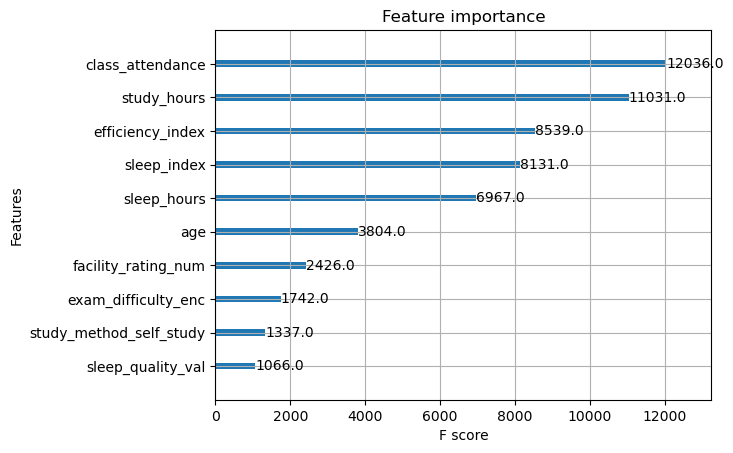

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
xgb.plot_importance(xgb_reg, max_num_features=10)
plt.show()

In [16]:
sys.path.append('../')
from src.utils import save_submission

preds = xgb_reg.predict(test_processed)
save_submission(preds, test)

🚀 提交文件已生成: ../submissions\sub_0108_2116.csv


'../submissions\\sub_0108_2116.csv'